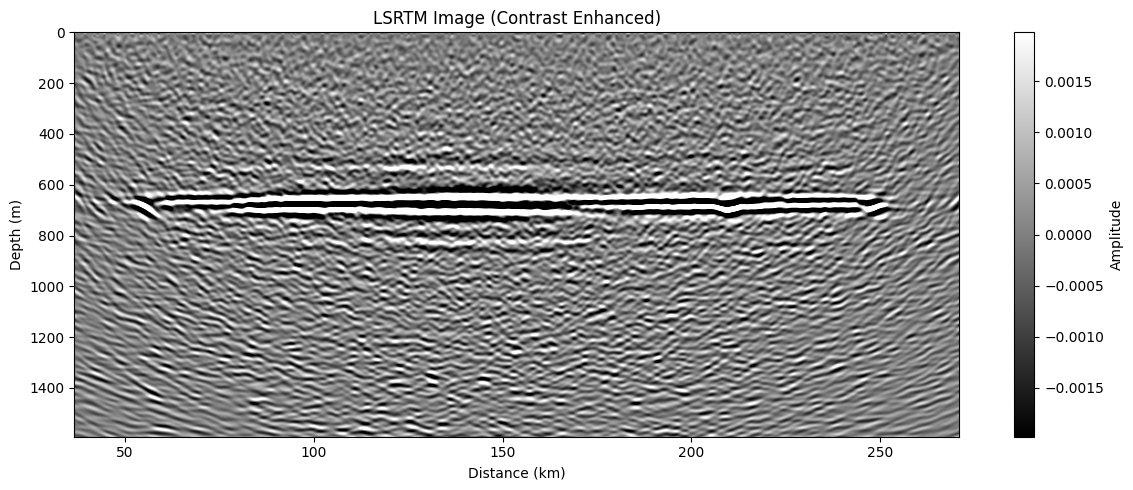

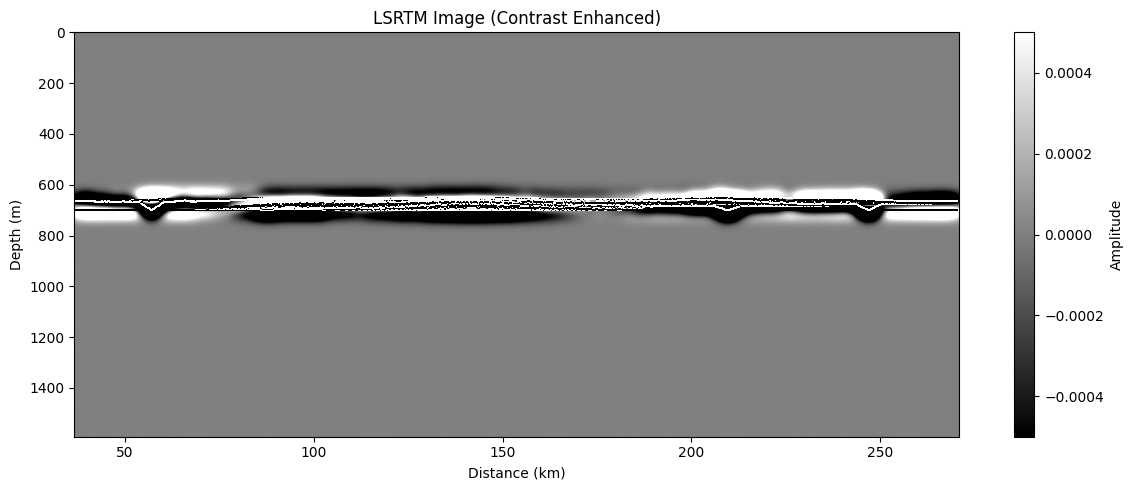

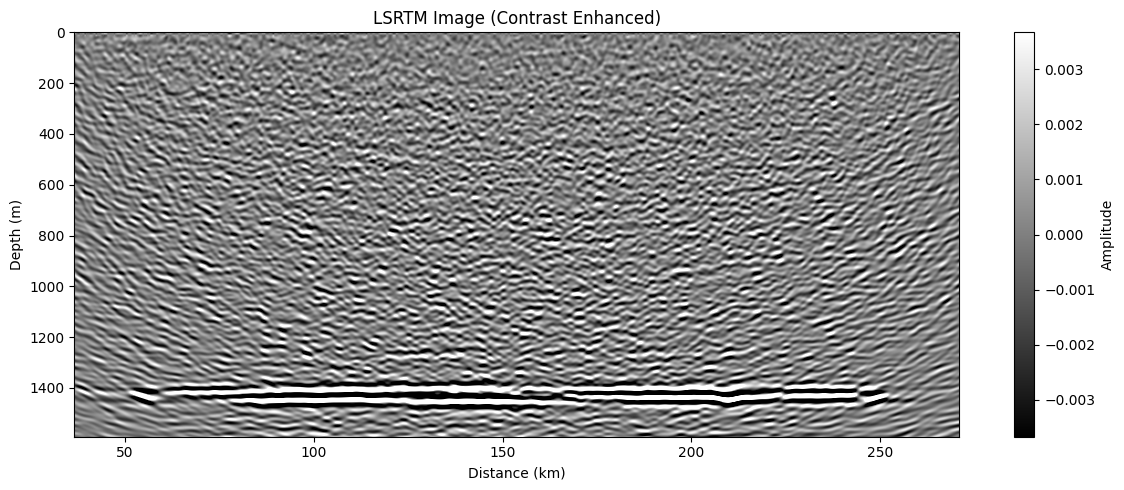

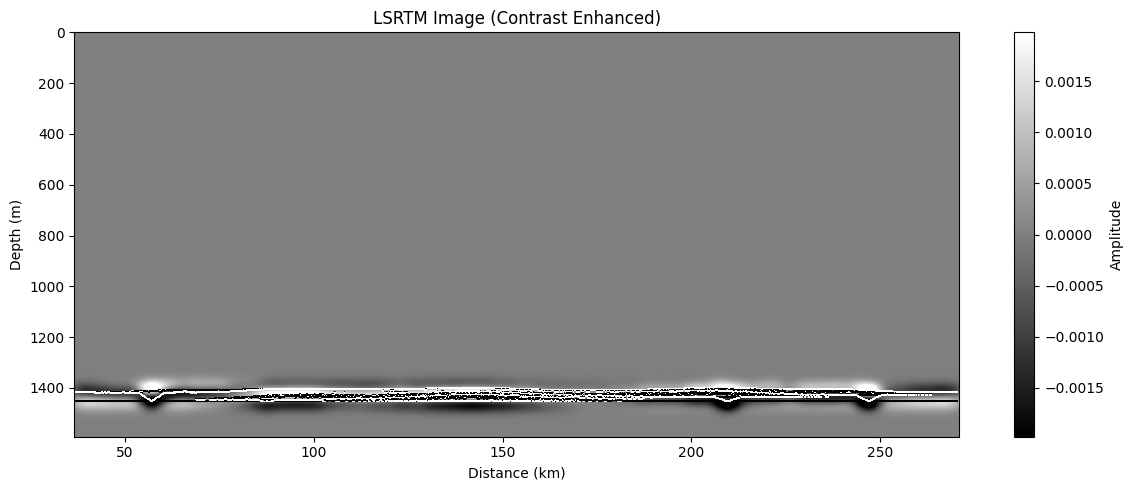

In [108]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ----------------------------------
# Parameters (you can modify)
# ----------------------------------
dx, dz = 4.0, 4.0   # grid spacing in meters
contrast_percentile = 95  # for clipping enhancement
apply_diff = True           # apply horizontal derivative

# ----------------------------------
# Load LSRTM image
# ----------------------------------
lsrtm = np.load("lsrtm_imageStkMulNOF30D15KUS4.npy")  # shape (nz, nx)
lsrtm2 = np.load("dmtrue_imageStkMulNOF30D15KUS4.npy")  # shape (nz, nx)
lsrtm3 = np.load("lsrtm_imageStkMulNOF30D15KDS4.npy")  # shape (nz, nx)
lsrtm4 = np.load("dmtrue_imageStkMulNOF30D15KDS4.npy")  # shape (nz, nx)
#lsrtm5 = np.load("lsrtm_imageS1B.npy")  # shape (nz, nx)

# ----------------------------------
# Optional contrast enhancement
# ----------------------------------
if apply_diff:
    img = np.diff(lsrtm, axis=1)
    img2 = np.diff(lsrtm2, axis=1)
    img3 = np.diff(lsrtm3, axis=1)
    img4 = np.diff(lsrtm4, axis=1)
    #img5 = np.diff(lsrtm5, axis=1)
else:
    img = lsrtm
    img2 = lsrtm2
    img3 = lsrtm3
    img4 = lsrtm4
    #img5 = lsrtm5

# Normalize using high-percentile clip
vmax = np.percentile(np.abs(img), contrast_percentile)
vmin = -vmax

vmax2 = np.percentile(np.abs(img2), contrast_percentile)
vmin2 = -vmax2

vmax3 = np.percentile(np.abs(img3), contrast_percentile)
vmin3 = -vmax3

#vmax4 = np.percentile(np.abs(img4), contrast_percentile)
#vmin4 = -vmax4

#vmax5 = np.percentile(np.abs(img5), contrast_percentile)
#vmin5 = -vmax5

# Optional: smooth image slightly (can help reduce noise)
#img = gaussian_filter(img, sigma=1)
#img3 = gaussian_filter(img3, sigma=1)

# ----------------------------------
# Define extents
# ----------------------------------
nx, nz = img.shape # shape changed from original supposed to be nz, nx
#nx3, nz3 = img3.shape # shape changed from original supposed to be nz, nx
#extent_m = [0, nx * dx, nz * dz, 0]
#extent_m3 = [0, nx3 * dx, nz3 * dz, 0]
#extent_km = [0, nx * dx / 1000, nz * dz / 1000, 0]

#actual Dip --- Define true horizontal extent in km ---
xmin_km = 36.7
xmax_km = 270.76
# Convert to meters for extent (imshow still needs meters)
xmin_m = xmin_km 
xmax_m = xmax_km
# Get depth extent in meters
dz = 4.0  # or your actual depth sampling
nz = img.shape[1]
zmax = 0
zmin = (nz - 1) * dz
extent_km = [xmin_m, xmax_m, zmin, zmax]

# ----------------------------------
# Plot in meters: cmap: seismic, bwr, coolwarm, Spectral, RdYlGn, RdYlBu, RdGy, PuOr, BrBG, PRGn, PiYG
# ----------------------------------
plt.figure(figsize=(12, 5))
plt.imshow(img.T, cmap="gray", aspect="auto", extent=extent_km, vmin=vmin, vmax=vmax) # bwr, RdGy, PuOr
plt.colorbar(label="Amplitude")
plt.title("LSRTM Image (Contrast Enhanced)")
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(img2.T, cmap="gray", aspect="auto", extent=extent_km, vmin=vmin2, vmax=vmax2) # bwr, RdGy, PuOr
plt.colorbar(label="Amplitude")
plt.title("LSRTM Image (Contrast Enhanced)")
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(img3.T, cmap="gray", aspect="auto", extent=extent_km, vmin=vmin3, vmax=vmax3)
plt.colorbar(label="Amplitude")
plt.title("LSRTM Image (Contrast Enhanced)")
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(img4.T, cmap="gray", aspect="auto", extent=extent_km, vmin=vmin, vmax=vmax) # bwr, RdGy, PuOr
plt.colorbar(label="Amplitude")
plt.title("LSRTM Image (Contrast Enhanced)")
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.tight_layout()
plt.show()

#plt.figure(figsize=(12, 5))
#plt.imshow(img5.T, cmap="seismic_r", aspect="auto", extent=extent_m, vmin=vmin5, vmax=vmax5) # bwr, RdGy, PuOr
#plt.colorbar(label="Amplitude")
#plt.title("LSRTM Image (Contrast Enhanced)")
#plt.xlabel("Distance (m)")
#plt.ylabel("Depth (m)")
#plt.grid(False)
#plt.tight_layout()
#plt.show()
# ----------------------------------
# Optional: Save figure
# ----------------------------------
# plt.savefig("lsrtm_image_enhanced.png", dpi=300, bbox_inches='tight')


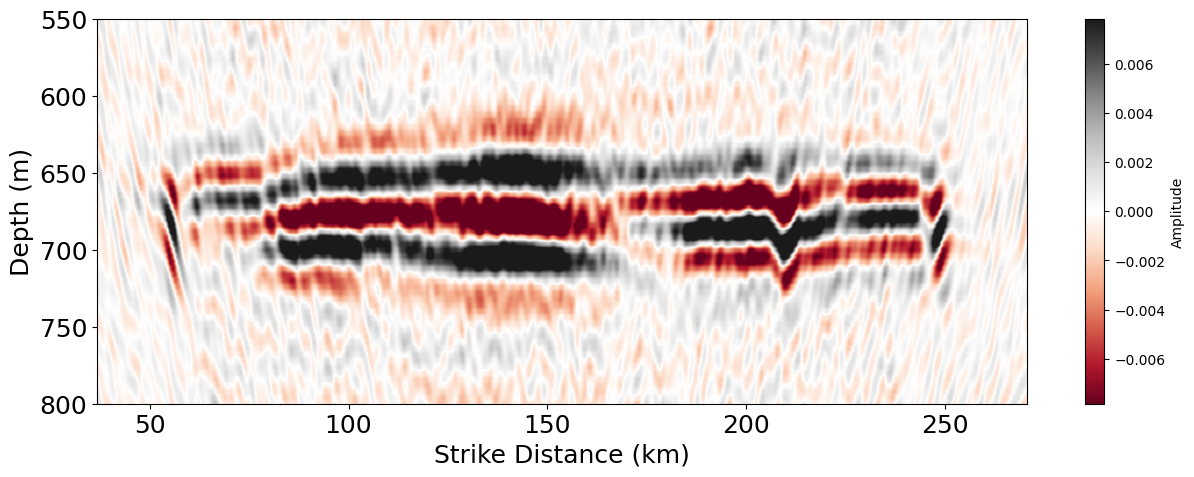

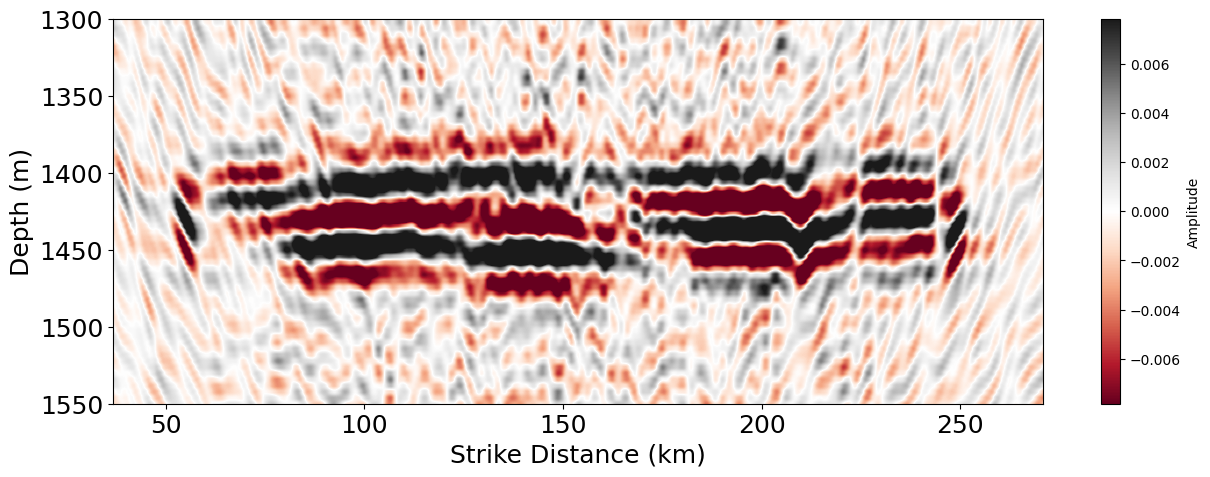

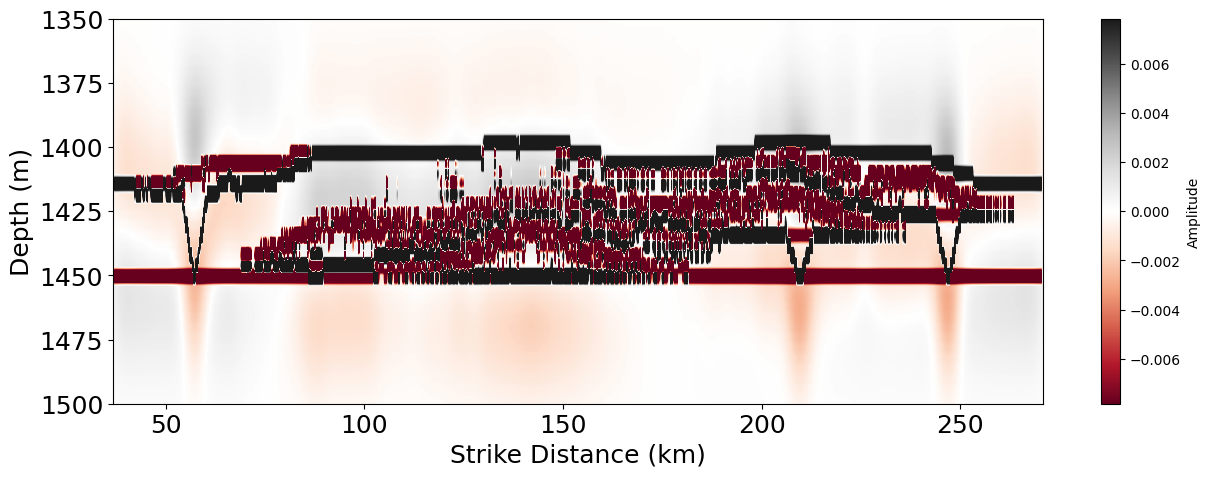

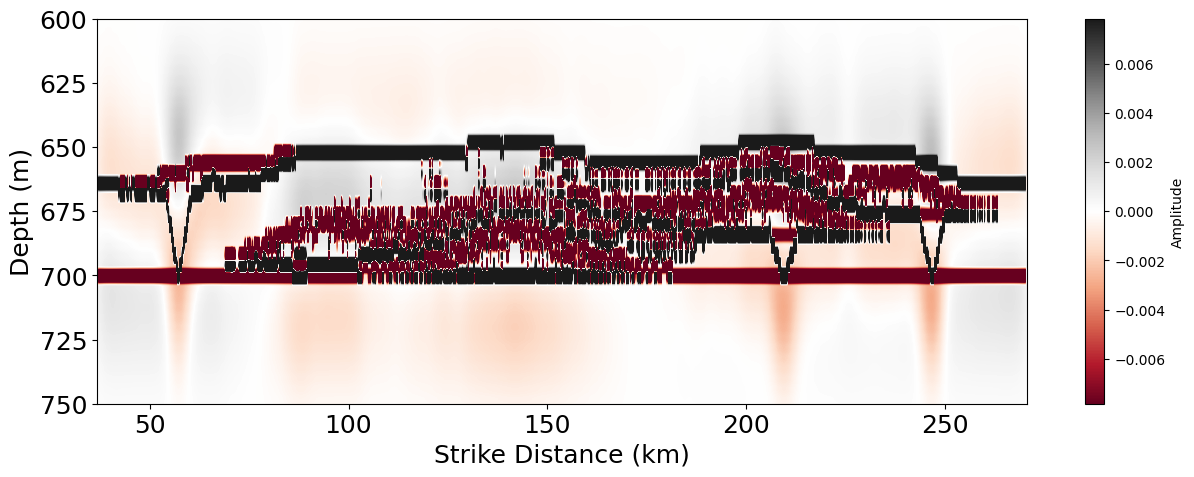

In [115]:
# Calculate horizontal extent in km
nx, nz = img.shape

#actual Strike
#dx = 87.5  # m per sample (adjust to your actual model spacing)
#x_start_km = 220.0
#x_end_km = x_start_km + (nx * dx) / 1000.0
#extent_km = [x_start_km, x_end_km, nz * dz, 0]  # [xmin, xmax, zmax, zmin]

#actual Dip --- Define true horizontal extent in km ---
xmin_km = 36.7
xmax_km = 270.76
# Convert to meters for extent (imshow still needs meters)
xmin_m = xmin_km 
xmax_m = xmax_km
# Get depth extent in meters
dz = 4.0  # or your actual depth sampling
nz = img.shape[1]
zmax = 0
zmin = (nz - 1) * dz
extent_km = [xmin_m, xmax_m, zmin, zmax]

#original
#dx, dz = 4.0, 4.0   # grid spacing in meters
#extent_m = [0, nx * dx, nz * dz, 0]

# Contrast normalization
contrast_percentile = 99
vmax = np.percentile(np.abs(img), contrast_percentile)
vmin = -vmax

# Plot
plt.figure(figsize=(15, 5))
plt.imshow(img.T, cmap='RdGy', aspect='auto', extent=extent_km, vmin=vmin, vmax=vmax)
plt.colorbar(label='Amplitude')
#plt.title('LSRTM Migrated Image (Vertical Derivative, Zoomed)')
plt.xlabel('Strike Distance (km)', fontsize=18)
plt.ylabel('Depth (m)', fontsize=18)
plt.ylim(800, 550)
plt.grid(False)
plt.tick_params(axis='both', which='major', labelsize=18)  # or any size you prefer
#plt.savefig('waveletF25Hz.pdf', bbox_inches='tight')  # Or use .png with dpi
#plt.savefig('DipF70S2U.png', bbox_inches='tight', dpi = 600)
plt.show()

plt.figure(figsize=(15, 5))
plt.imshow(img3.T, cmap='RdGy', aspect='auto', extent=extent_km, vmin=vmin, vmax=vmax)
plt.colorbar(label='Amplitude')
#plt.title('LSRTM Migrated Image (Vertical Derivative, Zoomed)')
plt.xlabel('Strike Distance (km)', fontsize=18)
plt.ylabel('Depth (m)', fontsize=18)
plt.ylim(1550, 1300)
plt.grid(False)
plt.tick_params(axis='both', which='major', labelsize=18)  # or any size you prefer
#plt.savefig('waveletF25Hz.pdf', bbox_inches='tight')  # Or use .png with dpi
#plt.savefig('DipF70S2D.png', bbox_inches='tight', dpi = 600)
plt.show()

plt.figure(figsize=(15, 5))
plt.imshow(img4.T, cmap='RdGy', aspect='auto', extent=extent_km, vmin=vmin, vmax=vmax)
plt.colorbar(label='Amplitude')
#plt.title('LSRTM Migrated Image (Vertical Derivative, Zoomed)')
plt.xlabel('Strike Distance (km)', fontsize=18)
plt.ylabel('Depth (m)', fontsize=18)
plt.ylim(1500, 1350)
plt.grid(False)
plt.tick_params(axis='both', which='major', labelsize=18)  # or any size you prefer
#plt.savefig('waveletF25Hz.pdf', bbox_inches='tight')  # Or use .png with dpi
plt.show()

plt.figure(figsize=(15, 5))
plt.imshow((img2.T), cmap='RdGy', aspect='auto', extent=extent_km, vmin=vmin, vmax=vmax)
plt.colorbar(label='Amplitude')
#plt.title('LSRTM Migrated Image (Vertical Derivative, Zoomed)')
plt.xlabel('Strike Distance (km)', fontsize=18)
plt.ylabel('Depth (m)', fontsize=18)
plt.ylim(750, 600)
plt.grid(False)
plt.tick_params(axis='both', which='major', labelsize=18)  # or any size you prefer
#plt.savefig('waveletF25Hz.pdf', bbox_inches='tight')  # Or use .png with dpi
plt.show()


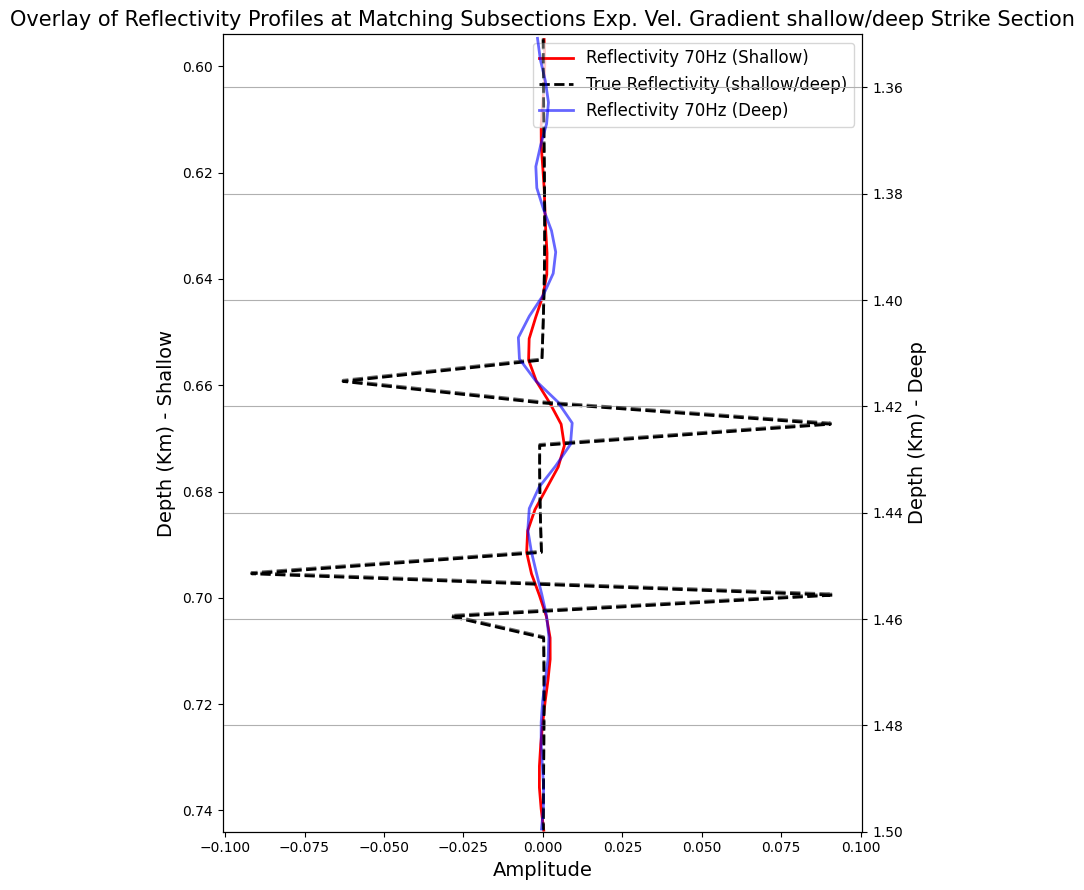

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load Data ---
ls = np.load("lsrtm_imageStkMulNOF30D15KUS4.npy")     # shape (nz, nx)
ls = np.diff(ls, axis=1)
dm = np.load("dmtrue_imageStkMulNOF30D15KUS4.npy")
dm = np.diff(dm, axis=1)
ls3 = np.load("lsrtm_imageStkMulNOF30D15KDS4.npy")
ls3 = np.diff(ls3, axis=1)
dm3 = np.load("dmtrue_imageStkMulNOF30D15KDS4.npy")
dm3 = np.diff(dm3, axis=1)

# --- Define Axes (vertical profiles assumed along row index = 375) ---
irow = 125
#x = np.linspace(0, 0.8, ls.shape[1])    # Horizontal distance (km) for shallow
x = np.linspace(0, 1.6, ls.shape[1])    # Horizontal distance (km) for shallow
x1 = np.linspace(0, 1.6, ls3.shape[1])  # Horizontal distance (km) for deep
#z_shallow = np.linspace(0, 0.8, ls.shape[0])  # Depth axis for shallow
z_shallow = np.linspace(0, 1.6, ls.shape[0])  # Depth axis for shallow
z_deep = np.linspace(0, 1.6, ls3.shape[0])    # Depth axis for deep

# --- Define Depth Ranges to Extract ---
#z1_min, z1_max = 0.596, 0.796  # Shallow slice for different depth
#z1_min, z1_max = 0.6, 0.75  # Shallow slice
z1_min, z1_max = 0.594, 0.744  # Shallow slice for same upper
#z1_min, z1_max = 0.747, 0.897  # Shallow slice for same upper S1
#z2_min, z2_max = 1.475, 1.6  # Deep slice
#z2_min, z2_max = 0.6, 0.8  # Deep slice for same upper
z2_min, z2_max = 1.35, 1.5  # Deep slice

# Convert to sample-level mask for row (375 is constant, so apply mask to columns)
depth_shallow = z_shallow[irow]
depth_deep = z_deep[irow]

# Create depth axes for plotting (x is vertical here!)
#x_depth_shallow = np.linspace(0, 0.8, ls.shape[1])
x_depth_shallow = np.linspace(0, 1.6, ls.shape[1])
x_depth_deep = np.linspace(0, 1.6, ls3.shape[1])

mask1 = (x_depth_shallow >= z1_min) & (x_depth_shallow <= z1_max)
mask2 = (x_depth_deep >= z2_min) & (x_depth_deep <= z2_max)

# --- Extract Plot Data ---
x_plot_1 = x_depth_shallow[mask1]
ls_plot = ls[irow, :][mask1]
dm_plot = dm[irow, :][mask1]

x_plot_2 = x_depth_deep[mask2]
ls3_plot = ls3[irow, :][mask2]
dm3_plot = dm3[irow, :][mask2]

# --- Save Data to Variables / CSV ---
plot_data_shallow = {
    'depth_km': x_plot_1,
    'lsrtm': ls_plot,
    'dm_true': dm_plot
}
plot_data_deep = {
    'depth_km': x_plot_2,
    'lsrtm': ls3_plot,
    'dm_true': dm3_plot
}

# Optional: export to CSV
#pd.DataFrame(plot_data_shallow).to_csv("shallow_reflectivity_profile.csv", index=False)
#pd.DataFrame(plot_data_deep).to_csv("deep_reflectivity_profile.csv", index=False)

# --- Plot Both on Shared Amplitude Axis ---
fig, ax1 = plt.subplots(figsize=(8, 9))

# LEFT Y-AXIS (shallow)
line1 = ax1.plot(ls_plot, x_plot_1, 'r', linewidth=2)
line2 = ax1.plot(dm_plot, x_plot_1, 'k--', linewidth=2)
ax1.set_ylabel("Depth (Km) - Shallow", fontsize=14)
ax1.set_xlabel("Amplitude", fontsize=14)
ax1.set_ylim(z1_max, z1_min)  # Inverted depth axis
ax1.tick_params(axis='y', labelcolor='black')

# RIGHT Y-AXIS (deep)
ax2 = ax1.twinx()
line3 = ax2.plot(ls3_plot, x_plot_2, 'b', linewidth=2, alpha=0.6)
line4 = ax2.plot(dm3_plot, x_plot_2, 'k--', linewidth=2, alpha=0.6)
ax2.set_ylabel("Depth (Km) - Deep", fontsize=14)
ax2.set_ylim(z2_max, z2_min)
ax2.tick_params(axis='y', labelcolor='black')

# Legend and title
lines = line1 + line2 + line3 + line4
labels = ['Reflectivity 70Hz (Shallow)', 'True Reflectivity (shallow/deep)',
          'Reflectivity 70Hz (Deep)']
#labels = ['Reflectivity 30Hz (shallow)', 'True Reflectivity (shallow/deep)',
#          'Reflectivity 30Hz (deep)', 'True Reflectivity (deep)']
ax1.legend(lines, labels, fontsize=12, loc='upper right')

plt.title("Overlay of Reflectivity Profiles at Matching Subsections Exp. Vel. Gradient shallow/deep Strike Section", fontsize=15)
plt.grid(True)
plt.tight_layout()
#plt.savefig('StkTraceAndTrueF30S4UNOS4DNO_700.png', bbox_inches='tight', dpi = 600)
plt.show()


In [130]:

import numpy as np
from scipy.fft import fft

def compute_metrics(pred, true):
    pred = np.array(pred)
    true = np.array(true)
    
    mse = np.mean((pred - true) ** 2)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(true) - np.min(true))

    signal_power = np.mean(true ** 2)
    noise_power = np.mean((true - pred) ** 2)
    snr_db = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else np.inf

    corr = np.corrcoef(pred, true)[0, 1]

    return {
        'MSE': mse,
        'NRMSE': nrmse,
        'SNR_dB': snr_db,
        'Correlation': corr
    }


# Shallow section
metrics_shallow = compute_metrics(
    plot_data_shallow['lsrtm'],
    plot_data_shallow['dm_true']
)

# Deep section
metrics_deep = compute_metrics(
    plot_data_deep['lsrtm'],
    #plot_data_deep['dm_true']
    plot_data_shallow['dm_true']
)



# signal semblance
def compute_ssc(signal1, signal2):
    # Remove mean to focus on reflectivity spectrum
    signal1 = signal1 - np.mean(signal1)
    signal2 = signal2 - np.mean(signal2)

    # Compute FFT
    fft1 = fft(signal1)
    fft2 = fft(signal2)

    # Use only positive frequencies
    A1 = np.abs(fft1[:len(fft1)//2])
    A2 = np.abs(fft2[:len(fft2)//2])

    # Normalize spectra
    A1_norm = A1 / np.linalg.norm(A1)
    A2_norm = A2 / np.linalg.norm(A2)

    # Compute cosine similarity (SSC)
    ssc = np.sum(A1_norm * A2_norm)

    return ssc


ssc_shallow = compute_ssc(
    plot_data_shallow['lsrtm'],
    plot_data_shallow['dm_true']
)

ssc_deep = compute_ssc(
    plot_data_deep['lsrtm'],
    plot_data_shallow['dm_true']
)



# Print results
print("Performance Metrics - Shallow Section:")
for k, v in metrics_shallow.items():
    print(f"{k}: {v:.4f}")

print("\nPerformance Metrics - Deep Section:")
for k, v in metrics_deep.items():
    print(f"{k}: {v:.4f}")

print('')
print(f"SSC - Shallow Section: {ssc_shallow:.4f}")
print(f"SSC - Deep Section:    {ssc_deep:.4f}")

Performance Metrics - Shallow Section:
MSE: 0.0007
NRMSE: 0.1491
SNR_dB: 0.2139
Correlation: 0.3082

Performance Metrics - Deep Section:
MSE: 0.0007
NRMSE: 0.1483
SNR_dB: 0.2646
Correlation: 0.3004

SSC - Shallow Section: 0.3357
SSC - Deep Section:    0.3698


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load Data ---
ls = np.load("lsrtm_imageStkMulNOF30D15KUS4.npy")     # trace scenario 1
ls = np.diff(ls, axis=1)
dm = np.load("dmtrue_imageStkMulNOF30D15KUS4.npy")   # trace scenario 2
dm = np.diff(dm, axis=1)
ls3 = np.load("lsrtm_imageStkMulNOF30D15KDS4.npy")   # true reflectivity
ls3 = np.diff(ls3, axis=1)


# --- Define Axes (vertical profiles assumed along row index = 375) ---
irow = 500
#x = np.linspace(0, 0.8, ls.shape[1])    # Horizontal distance (km) for shallow
x = np.linspace(0, 1.6, ls.shape[1])    # Horizontal distance (km) for shallow
x1 = np.linspace(0, 1.6, ls3.shape[1])  # Horizontal distance (km) for deep
z_shallow = np.linspace(0, 1.6, ls.shape[0])  # Depth axis for shallow
z_deep = np.linspace(0, 1.6, ls3.shape[0])    # Depth axis for deep

# --- Define Depth Ranges to Extract ---
z1_min, z2_max = 0.6, 0.8  # Shallow slice 
z2_min, z2_max = 1.35, 1.5  # Deep slice

# Convert to sample-level mask for row (375 is constant, so apply mask to columns)
depth_shallow = z_shallow[irow]
depth_deep = z_deep[irow]

# Create depth axes for plotting (x is vertical here!)
x_depth_shallow = np.linspace(0, 1.6, ls.shape[1])
x_depth_deep = np.linspace(0, 1.6, ls3.shape[1])

mask1 = (x_depth_shallow >= z1_min) & (x_depth_shallow <= z1_max)
mask2 = (x_depth_deep >= z2_min) & (x_depth_deep <= z2_max)

# --- Extract Plot Data ---
x_plot_1 = x_depth_shallow[mask1]
ls_plot = ls[irow, :][mask1]
dm_plot = dm[irow, :][mask1]

x_plot_2 = x_depth_deep[mask2]
ls3_plot = ls3[irow, :][mask2]
dm_plot = dm3[irow, :][mask2]

# --- Save Data to Variables / CSV ---
plot_data_shallow = {
    'depth_km': x_plot_1,
    'lsrtm': ls_plot,
    'dm_true': dm_plot
}
plot_data_deep = {
    'depth_km': x_plot_2,
    'lsrtm': ls3_plot,
    'dm_true': dm_plot
}



# --- Plot Both on Shared Amplitude Axis ---
fig, ax1 = plt.subplots(figsize=(8, 9))

# LEFT Y-AXIS (shallow)
line1 = ax1.plot(ls_plot, x_plot_1, 'r', linewidth=2)
line2 = ax1.plot(dm_plot, x_plot_1, 'k--', linewidth=2)
ax1.set_ylabel("Depth (Km) - Shallow", fontsize=14)
ax1.set_xlabel("Amplitude", fontsize=14)
ax1.set_ylim(z1_max, z1_min)  # Inverted depth axis
ax1.tick_params(axis='y', labelcolor='black')

# RIGHT Y-AXIS (deep)
ax2 = ax1.twinx()
line3 = ax2.plot(ls3_plot, x_plot_2, 'b', linewidth=2, alpha=0.6)
line4 = ax2.plot(dm3_plot, x_plot_2, 'k--', linewidth=2, alpha=0.6)
ax2.set_ylabel("Depth (Km) - Deep", fontsize=14)
ax2.set_ylim(z2_max, z2_min)
ax2.tick_params(axis='y', labelcolor='black')

# Legend and title
lines = line1 + line2 + line3 + line4
labels = ['Reflectivity 70Hz (Shallow)', 'True Reflectivity (shallow/deep)',
          'Reflectivity 70Hz (Deep)']
ax1.legend(lines, labels, fontsize=12, loc='upper right')

plt.title("Overlay of Reflectivity Profiles at Matching Subsections Exp. Vel. Gradient shallow/deep Strike Section", fontsize=15)
plt.grid(True)
plt.tight_layout()
#plt.savefig('StkTraceAndTrueF30S4UNOS4DNO_700.png', bbox_inches='tight', dpi = 600)
plt.show()